<center>

<img src='https://micro.ce.sharif.edu/lib/tpl/writr/images/logo.svg' alt="SUT logo" width=500 height=300 align=center class="saturate" >


<br>
<font>
<div dir=ltr align=center>
<font color=0F5298 size=7>
    Intelligent Analysis of Biomedical Images <br>
<font color=2565AE size=5>
    Computer Engineering Department <br>
    Dr. Rohban, Fall 2025 <br>
<font color=3C99D size=5>
    Practical Assignment HW4 - Q2 - Image Registration with VoxelMorph <br>
<font color=696880 size=4>
    By: Ali Hajisadeghian

</center>


**Student Name:** `Reyhane Khayatzade Mahnani`  
**Student ID:** `402105965`

In [1]:
# ============================================================
# Cell 1 — Imports & Device Setup
# DO NOT MODIFY THIS CELL
# ============================================================

import os
import time
import numpy as np
import matplotlib.pyplot as plt
import random


from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as nnf
from torch.utils.data import DataLoader, Dataset

import tempfile


# Set device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [2]:
# ============================================================
# Cell 2 — Install MONAI (Colab) & Print Configuration
# DO NOT MODIFY THIS CELL
# ============================================================

# In Google Colab, MONAI may not be pre-installed
try:
    import monai
except ImportError:
    !pip install monai --quiet
    import monai

# MONAI
from monai.transforms import (
    Compose,
    LoadImageD,
    EnsureChannelFirstD,
    ScaleIntensityRanged,
    RandRotateD,
    RandZoomD,
)
from monai.data import Dataset as MONAIDataset, CacheDataset
from monai.config import print_config, USE_COMPILED
from monai.apps import MedNISTDataset

print("MONAI Version Information:")
print_config()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 50.2 MB/s eta 0:00:00


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


MONAI Version Information:
MONAI version: 1.5.2
Numpy version: 2.0.2
Pytorch version: 2.10.0+cu128
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d18565fb3e4fd8c556707f91ac280a2dc3f681c1
MONAI __file__: /usr/local/lib/python3.12/dist-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: 5.3.3
scikit-image version: 0.25.2
scipy version: 1.16.3
Pillow version: 11.3.0
Tensorboard version: 2.19.0
gdown version: 5.2.1
TorchVision version: 0.25.0+cu128
tqdm version: 4.67.3
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 5.9.5
pandas version: 2.2.2
einops version: 0.8.2
transformers version: 5.0.0
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT INSTALLED or UNKNOWN VERSION.

For details about installing the optional dependencies, please visit:
    

In [3]:
# ============================================================
# Cell 3 — Download MedNIST & Construct HeadCT Data Dict
# DO NOT MODIFY THIS CELL
# ============================================================

# Set root directory for MONAI data
directory = os.environ.get("MONAI_DATA_DIRECTORY")
if directory is not None:
    os.makedirs(directory, exist_ok=True)
root_dir = tempfile.mkdtemp() if directory is None else directory
print("Data root directory:", root_dir)

# Download MedNIST (training section)
train_data = MedNISTDataset(root_dir=root_dir, section="training", download=True, transform=None)

# MedNIST class mapping is fixed:
# 0: AbdomenCT, 1: BreastMRI, 2: CXR, 3: ChestCT, 4: Hand, 5: HeadCT
HEADCT_LABEL = 5

# Build training data dict:
# "fixed_img"  = original head CT slice
# "moving_img" = same image (will be augmented later)
training_datadict = [
    {"fixed_img": item["image"], "moving_img": item["image"]}
    for item in train_data.data
    if item["label"] == HEADCT_LABEL
]

print(f"Number of HeadCT samples: {len(training_datadict)}")
print("First 3 items:", training_datadict[:3])


Data root directory: /tmp/tmph6hq01g_


MedNIST.tar.gz: 59.0MB [00:00, 83.5MB/s]                           

2026-02-20 11:43:35,310 - INFO - Downloaded: /tmp/tmph6hq01g_/MedNIST.tar.gz


2026-02-20 11:43:35,426 - INFO - Verified 'MedNIST.tar.gz', md5: 0bc7306e7427e00ad1c5526a6677552d.
2026-02-20 11:43:35,427 - INFO - Writing into directory: /tmp/tmph6hq01g_.


Loading dataset: 100%|██████████| 47164/47164 [00:00<00:00, 125191.77it/s]

Number of HeadCT samples: 7991
First 3 items: [{'fixed_img': '/tmp/tmph6hq01g_/MedNIST/HeadCT/008325.jpeg', 'moving_img': '/tmp/tmph6hq01g_/MedNIST/HeadCT/008325.jpeg'}, {'fixed_img': '/tmp/tmph6hq01g_/MedNIST/HeadCT/007976.jpeg', 'moving_img': '/tmp/tmph6hq01g_/MedNIST/HeadCT/007976.jpeg'}, {'fixed_img': '/tmp/tmph6hq01g_/MedNIST/HeadCT/005645.jpeg', 'moving_img': '/tmp/tmph6hq01g_/MedNIST/HeadCT/005645.jpeg'}]


In [4]:
# ============================================================
# Cell 4 — Define MONAI Transforms (Fixed vs Moving)
# DO NOT MODIFY THIS CELL
# ============================================================

train_transforms = Compose([
    # Load both fixed and moving images from file paths
    LoadImageD(keys=["fixed_img", "moving_img"]),

    # Ensure shape: (C, H, W)
    EnsureChannelFirstD(keys=["fixed_img", "moving_img"]),

    # Normalize intensity to [0, 1]
    ScaleIntensityRanged(
        keys=["fixed_img", "moving_img"],
        a_min=0.0,
        a_max=255.0,
        b_min=0.0,
        b_max=1.0,
        clip=True,
    ),

    # ---- Augment ONLY the moving image ----
    # Apply a random rotation (±45 degrees)
    RandRotateD(
        keys=["moving_img"],
        range_x=np.pi / 4,
        prob=1.0,
        keep_size=True,
        mode="bicubic"
    ),

    # Apply random zoom (0.9x to 1.1x)
    RandZoomD(
        keys=["moving_img"],
        min_zoom=0.9,
        max_zoom=1.1,
        prob=1.0,
        mode="bicubic",
        align_corners=False
    ),
])

print("Transforms defined successfully.")


Transforms defined successfully.


In [5]:
# ============================================================
# Cell 5 — Create Train/Validation Datasets & DataLoaders
# DO NOT MODIFY THIS CELL
# ============================================================

# Limit the number of samples for speed (especially in Colab)
max_train_samples = 200
max_val_samples = 50

num_total = len(training_datadict)
if num_total < 2:
    raise ValueError("Not enough HeadCT samples in MedNIST to build train/val sets.")

# Simple split: first ~70% for train, rest for val
n_train = int(0.7 * num_total)
n_train = min(n_train, max_train_samples)
n_val = min(num_total - n_train, max_val_samples)

train_data_dicts = training_datadict[:n_train]
val_data_dicts = training_datadict[n_train:n_train + n_val]

print(f"Using {len(train_data_dicts)} samples for training.")
print(f"Using {len(val_data_dicts)} samples for validation.")


Using 200 samples for training.
Using 50 samples for validation.


In [6]:
# ============================================================
# Cell 6 — Per-Student Randomness Seed (SID-Based)
# DO NOT MODIFY THIS CELL
# ============================================================

# Ask student for SID
SID = input("Enter your Student ID (SID): ").strip()

if len(SID) == 0:
    raise ValueError("SID cannot be empty.")

# Convert SID → integer seed
seed = sum(ord(c) for c in SID)  # simple, stable hash
print(f"Derived seed from SID = {seed}")

# Set all random seeds (PyTorch, NumPy, Python)
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# Make DataLoader deterministic
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Random seeds set. Your results will be unique to your SID.")

# ------------------------------------------------------------
# Student-specific dataset slicing
# ------------------------------------------------------------

# We use the seed to choose a unique start offset in training/validation sets.
offset_train = seed % 10      # shift dataset by up to 10 samples
offset_val   = (seed // 7) % 10

# Apply offset cyclically
train_data_dicts = train_data_dicts[offset_train:] + train_data_dicts[:offset_train]
val_data_dicts   = val_data_dicts[offset_val:]   + val_data_dicts[:offset_val]

print(f"Applied student-specific dataset shift: train offset = {offset_train}, val offset = {offset_val}")

# ------------------------------------------------------------
# Student-specific augmentation adjustment
# ------------------------------------------------------------

# Slightly vary rotation range and zoom range based on SID
# These changes are small but ensure unique results.
rot_scale = 0.8 + (seed % 5) * 0.05      # between 0.80 and 1.00
zoom_shift = ((seed % 3) - 1) * 0.02     # between -0.02, 0, +0.02

# We patch the transform objects directly
for t in train_transforms.transforms:
    if isinstance(t, RandRotateD):
        t.range_x = rot_scale * (np.pi / 4)
    if isinstance(t, RandZoomD):
        t.min_zoom = max(0.85, 0.9 + zoom_shift)
        t.max_zoom = min(1.15, 1.1 + zoom_shift)

print("Applied student-specific augmentation parameters:")
print(f" - Rotation scale factor: {rot_scale:.3f}")
print(f" - Zoom shift: {zoom_shift:+.3f}")

print("\nPer-student configuration complete.")


Enter your Student ID (SID): 402105965
Derived seed from SID = 464
Random seeds set. Your results will be unique to your SID.
Applied student-specific dataset shift: train offset = 4, val offset = 6
Applied student-specific augmentation parameters:
 - Rotation scale factor: 1.000
 - Zoom shift: +0.020

Per-student configuration complete.


Loading dataset: 100%|██████████| 50/50 [00:00<00:00, 330.57it/s]


Fixed batch shape: torch.Size([2, 1, 64, 64])
Moving batch shape: torch.Size([2, 1, 64, 64])


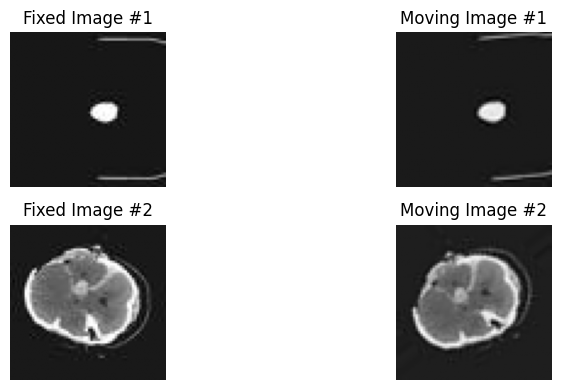

In [7]:
# ============================================================
# Cell 7 — Sanity Check: Visualize Fixed & Moving Images
# DO NOT MODIFY THIS CELL
# ============================================================

# Re-build datasets and loaders with updated (SID-shifted) lists
# Rebuild train and val datasets/loaders after SID-based shifts and transform tweaks

train_ds = CacheDataset(
    data=train_data_dicts,
    transform=train_transforms,
    cache_rate=1.0,
    num_workers=2,
)

val_ds = CacheDataset(
    data=val_data_dicts,
    transform=train_transforms,
    cache_rate=1.0,
    num_workers=2,
)

batch_size = 16

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
)

val_loader = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
)

viz_loader = DataLoader(
    train_ds,
    batch_size=2,        # small batch for visualization
    shuffle=True,
    num_workers=2,
)

# Fetch one random batch
batch = next(iter(viz_loader))
fixed_batch = batch["fixed_img"]
moving_batch = batch["moving_img"]

print("Fixed batch shape:", fixed_batch.shape)
print("Moving batch shape:", moving_batch.shape)

# Plot first two samples in batch
plt.figure(figsize=(10, 4))

for i in range(2):  # show up to 2 samples
    # Fixed image
    plt.subplot(2, 2, 2*i + 1)
    plt.title(f"Fixed Image #{i+1}")
    plt.imshow(fixed_batch[i][0].cpu(), cmap="gray")
    plt.axis("off")

    # Moving image (augmented)
    plt.subplot(2, 2, 2*i + 2)
    plt.title(f"Moving Image #{i+1}")
    plt.imshow(moving_batch[i][0].cpu(), cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()


In [8]:
# ============================================================
# Cell 8 — U-Net + Helper Blocks
# DO NOT MODIFY THIS CELL
# ============================================================

# -----------------------------
# Basic Conv Block
# -----------------------------
class ConvBlock(nn.Module):
    """
    Convolution + LeakyReLU block used throughout the U-Net.
    """
    def __init__(self, ndims, in_channels, out_channels):
        super().__init__()
        Conv = getattr(nn, f"Conv{ndims}d")
        self.main = Conv(in_channels, out_channels, kernel_size=3, padding=1)
        self.activation = nn.LeakyReLU(0.2)

    def forward(self, x):
        return self.activation(self.main(x))


# -----------------------------
# U-Net Backbone
# -----------------------------
class Unet(nn.Module):
    """
    Multi-level encoder–decoder U-Net with skip connections.
    Used inside VoxelMorph to predict dense flow fields.
    """
    def __init__(
        self,
        inshape,
        infeats,
        nb_features=None,
        nb_levels=None,
        feat_mult=1,
        nb_conv_per_level=1,
        max_pool=2,
        half_res=False,
    ):
        super().__init__()

        ndims = len(inshape)
        self.half_res = half_res

        # Default U-Net feature config (VXM paper)
        if nb_features is None:
            enc_nf = [16, 32, 32, 32]
            dec_nf = [32, 32, 32, 32, 32, 16, 16]
            nb_features = [enc_nf, dec_nf]

        # If user gives a single integer, autogenerate feature pyramid
        if isinstance(nb_features, int):
            if nb_levels is None:
                raise ValueError("If nb_features is an int, nb_levels must be provided.")
            feats = np.round(nb_features * feat_mult ** np.arange(nb_levels)).astype(int)
            nb_features = [
                np.repeat(feats[:-1], nb_conv_per_level),
                np.repeat(np.flip(feats), nb_conv_per_level),
            ]
        elif nb_levels is not None:
            raise ValueError("nb_levels cannot be used when nb_features is a list.")

        enc_nf, dec_nf = nb_features
        nb_dec_convs = len(enc_nf)
        final_convs = dec_nf[nb_dec_convs:]
        dec_nf = dec_nf[:nb_dec_convs]
        self.nb_levels = int(nb_dec_convs / nb_conv_per_level) + 1

        # Max pooling / upsampling ops
        if isinstance(max_pool, int):
            max_pool = [max_pool] * self.nb_levels

        Pool = getattr(nn, f"MaxPool{ndims}d")
        self.pooling = [Pool(s) for s in max_pool]
        self.upsampling = [nn.Upsample(scale_factor=s, mode="nearest") for s in max_pool]

        # -----------------------------
        # Encoder
        # -----------------------------
        prev_nf = infeats
        enc_features = [prev_nf]  # for skip connections
        self.encoder = nn.ModuleList()

        for level in range(self.nb_levels - 1):
            convs = nn.ModuleList()
            for conv in range(nb_conv_per_level):
                nf = enc_nf[level * nb_conv_per_level + conv]
                convs.append(ConvBlock(ndims, prev_nf, nf))
                prev_nf = nf
            self.encoder.append(convs)
            enc_features.append(prev_nf)

        # -----------------------------
        # Decoder
        # -----------------------------
        enc_features = np.flip(enc_features)
        self.decoder = nn.ModuleList()

        for level in range(self.nb_levels - 1):
            convs = nn.ModuleList()
            for conv in range(nb_conv_per_level):
                nf = dec_nf[level * nb_conv_per_level + conv]
                convs.append(ConvBlock(ndims, prev_nf, nf))
                prev_nf = nf

            self.decoder.append(convs)
            if not half_res or level < (self.nb_levels - 2):
                prev_nf += enc_features[level]

        # Remaining full-res convs
        self.remaining = nn.ModuleList()
        for nf in final_convs:
            self.remaining.append(ConvBlock(ndims, prev_nf, nf))
            prev_nf = nf

        self.final_nf = prev_nf

    # -----------------------------
    # Forward Pass
    # -----------------------------
    def forward(self, x):
        # Encoder
        skip_connections = [x]
        for level, convs in enumerate(self.encoder):
            for conv in convs:
                x = conv(x)
            skip_connections.append(x)
            x = self.pooling[level](x)

        # Decoder
        for level, convs in enumerate(self.decoder):
            for conv in convs:
                x = conv(x)
            if not self.half_res or level < (self.nb_levels - 2):
                x = self.upsampling[level](x)
                x = torch.cat([x, skip_connections.pop()], dim=1)

        # Remaining convs
        for conv in self.remaining:
            x = conv(x)

        return x


In [9]:
# ============================================================
# Cell 9 — SpatialTransformer, VecInt, ResizeTransform
# DO NOT MODIFY THIS CELL
# ============================================================

class SpatialTransformer(nn.Module):
    """
    N-D Spatial Transformer

    Given a source image and a flow field, warps the source image.
    Uses a pre-computed sampling grid plus the flow field, and
    image interpolation is performed via torch.nn.functional.grid_sample.
    """

    def __init__(self, size, mode='bilinear'):
        """
        Parameters:
            size: Tuple specifying spatial size, e.g. (64, 64) for 2D.
            mode: Interpolation mode for grid_sample.
        """
        super().__init__()

        self.mode = mode

        # create sampling grid (in voxel coordinates)
        vectors = [torch.arange(0, s) for s in size]  # e.g. [0..H-1], [0..W-1]
        grids = torch.meshgrid(*vectors, indexing="ij")
        grid = torch.stack(grids)  # (ndims, *size)
        grid = torch.unsqueeze(grid, 0)  # (1, ndims, *size)
        grid = grid.type(torch.FloatTensor)

        # register grid as buffer so it moves to GPU with the module
        self.register_buffer("grid", grid)

    def forward(self, src, flow):
        """
        Parameters:
            src: source image, shape (B, C, *size)
            flow: flow field, shape (B, ndims, *size)

        Returns:
            Warped image with same shape as src.
        """
        # new voxel locations: grid + flow
        new_locs = self.grid + flow
        shape = flow.shape[2:]  # spatial dims

        # normalize to [-1, 1] for grid_sample
        # foreach dimension i: x_i_norm = 2 * (x_i / (size_i - 1) - 0.5)
        for i in range(len(shape)):
            new_locs[:, i, ...] = 2.0 * (new_locs[:, i, ...] / (shape[i] - 1.0) - 0.5)

        # move channels dimension to last position and invert order for grid_sample
        if len(shape) == 2:
            # (B, 2, H, W) -> (B, H, W, 2) and swap x/y
            new_locs = new_locs.permute(0, 2, 3, 1)
            new_locs = new_locs[..., [1, 0]]
        elif len(shape) == 3:
            # (B, 3, D, H, W) -> (B, D, H, W, 3) and swap z/y/x → x/y/z
            new_locs = new_locs.permute(0, 2, 3, 4, 1)
            new_locs = new_locs[..., [2, 1, 0]]

        # sample using grid_sample
        return nnf.grid_sample(src, new_locs, mode=self.mode, align_corners=True)


class VecInt(nn.Module):
    """
    Integrates a vector (flow) field via scaling and squaring.

    This is used to obtain a diffeomorphic warp by integrating a
    stationary velocity field over time.
    """

    def __init__(self, inshape, nsteps):
        """
        Parameters:
            inshape: Spatial size, e.g. (64, 64).
            nsteps:  Number of scaling and squaring steps (>= 0).
        """
        super().__init__()

        assert nsteps >= 0, f"nsteps should be >= 0, got {nsteps}"
        self.nsteps = nsteps
        self.scale = 1.0 / (2 ** self.nsteps)
        self.transformer = SpatialTransformer(inshape)

    def forward(self, vec):
        """
        Parameters:
            vec: Velocity field, shape (B, ndims, *size)

        Returns:
            Integrated flow field of same shape.
        """
        # scale field first
        vec = vec * self.scale
        for _ in range(self.nsteps):
            vec = vec + self.transformer(vec, vec)
        return vec


class ResizeTransform(nn.Module):
    """
    Resize a transform (flow field), which involves:
    - resizing the vector field,
    - and rescaling its magnitude accordingly.
    """

    def __init__(self, vel_resize, ndims):
        """
        Parameters:
            vel_resize: resize factor (e.g., 2 means half-size; 0.5 means double-size).
            ndims:      number of spatial dimensions (2 or 3).
        """
        super().__init__()
        self.factor = 1.0 / vel_resize

        mode = "linear"
        if ndims == 2:
            mode = "bi" + mode   # bilinear
        elif ndims == 3:
            mode = "tri" + mode  # trilinear

        self.mode = mode

    def forward(self, x):
        """
        Parameters:
            x: flow field, shape (B, ndims, *size)

        Returns:
            Resized and rescaled flow field.
        """
        if self.factor < 1.0:
            # shrink then scale down, to save memory
            x = nnf.interpolate(x, scale_factor=self.factor, mode=self.mode, align_corners=True)
            x = self.factor * x
        elif self.factor > 1.0:
            # scale up then upsample
            x = self.factor * x
            x = nnf.interpolate(x, scale_factor=self.factor, mode=self.mode, align_corners=True)
        return x


In [10]:
# ============================================================
# Cell 10 — VxmDense Model Definition & Initialization
# DO NOT MODIFY THIS CELL
# ============================================================

class VxmDense(nn.Module):
    """
    VoxelMorph-style network for (unsupervised) nonlinear registration
    between two images.

    Given:
        source (moving) image
        target (fixed) image

    it predicts a dense flow field that warps the source toward the target.
    """

    def __init__(
        self,
        inshape,
        nb_unet_features=None,
        nb_unet_levels=None,
        unet_feat_mult=1,
        nb_unet_conv_per_level=1,
        int_steps=7,
        int_downsize=2,
        use_probs=False,
        src_feats=1,
        trg_feats=1,
        unet_half_res=False,
    ):
        """
        Parameters:
            inshape: spatial size, e.g. (64, 64) for 2D.
            nb_unet_features: Unet convolutional features. Either:
                - list [enc_nf, dec_nf], or
                - single integer, in which case nb_unet_levels must be provided.
            nb_unet_levels: number of unet levels (if nb_unet_features is int).
            unet_feat_mult: feature multiplier per level (if nb_unet_features is int).
            nb_unet_conv_per_level: convs per level in unet.
            int_steps: number of steps for flow integration (0 = no integration).
            int_downsize: flow downsample factor for integration.
            use_probs: (not used here; set False).
            src_feats: channels in source image.
            trg_feats: channels in target image.
            unet_half_res: skip last unet upsampling (requires int_downsize=2).
        """
        super().__init__()

        # internal flag: typically we want integrated flow at test time
        self.training = True

        # number of spatial dims
        ndims = len(inshape)
        assert ndims in [1, 2, 3], f"ndims must be 1, 2, or 3, got {ndims}"

        # Configure core Unet
        self.unet_model = Unet(
            inshape=inshape,
            infeats=src_feats + trg_feats,
            nb_features=nb_unet_features,
            nb_levels=nb_unet_levels,
            feat_mult=unet_feat_mult,
            nb_conv_per_level=nb_unet_conv_per_level,
            half_res=unet_half_res,
        )

        # Flow head: maps Unet features → ndims flow field
        Conv = getattr(nn, f"Conv{ndims}d")
        self.flow = Conv(self.unet_model.final_nf, ndims, kernel_size=3, padding=1)

        # Initialize flow layer with small weights and zero bias
        from torch.distributions.normal import Normal
        self.flow.weight = nn.Parameter(Normal(0, 1e-5).sample(self.flow.weight.shape))
        self.flow.bias = nn.Parameter(torch.zeros_like(self.flow.bias))

        if use_probs:
            raise NotImplementedError(
                "Flow variance (use_probs=True) has not been implemented in this PyTorch version."
            )

        # Optional resize layers (for integrating at lower resolution)
        if not unet_half_res and int_steps > 0 and int_downsize > 1:
            self.resize = ResizeTransform(int_downsize, ndims)
        else:
            self.resize = None

        # Resize back to full resolution after integration
        if int_steps > 0 and int_downsize > 1:
            self.fullsize = ResizeTransform(1.0 / int_downsize, ndims)
        else:
            self.fullsize = None

        # Integrator for diffeomorphic warp
        down_shape = [int(dim / int_downsize) for dim in inshape]
        self.integrate = VecInt(down_shape, int_steps) if int_steps > 0 else None

        # Spatial transformer
        self.transformer = SpatialTransformer(inshape)

    def forward(self, source, target, registration=False):
        """
        Parameters:
            source: moving image tensor, shape (B, C, *inshape)
            target: fixed  image tensor, shape (B, C, *inshape)
            registration: if True, return integrated full-res flow

        Returns:
            y_source: warped source image
            flow:     flow field (pre-integration if training, or full flow if registration=True)
        """
        # Concatenate moving and fixed along channel dim
        x = torch.cat([source, target], dim=1)
        x = self.unet_model(x)

        # Predict flow field
        flow_field = self.flow(x)

        # For integration, possibly resize flow
        pos_flow = flow_field
        if self.resize is not None:
            pos_flow = self.resize(pos_flow)
        preint_flow = pos_flow

        # Integrate to get diffeomorphic warp
        if self.integrate is not None:
            pos_flow = self.integrate(pos_flow)
            if self.fullsize is not None:
                pos_flow = self.fullsize(pos_flow)

        # Warp source with flow
        y_source = self.transformer(source, pos_flow)

        # During training, typically return non-integrated flow
        if not registration:
            return y_source, preint_flow
        else:
            return y_source, pos_flow


# ------------------------------------------------------------
# Instantiate 2D VoxelMorph model for 64x64 HeadCT images
# ------------------------------------------------------------

inshape = (64, 64)            # spatial size for MedNIST HeadCT after transforms
enc_nf = [16, 32, 32, 32]     # encoder features
dec_nf = [32, 32, 32, 32, 32, 16, 16]  # decoder features

voxelmorph = VxmDense(
    inshape=inshape,
    nb_unet_features=[enc_nf, dec_nf],
    src_feats=1,   # grayscale
    trg_feats=1,
)

voxelmorph = voxelmorph.to(device)
print("VxmDense model initialized on device:", device)


VxmDense model initialized on device: cuda


In [11]:
# ============================================================
# Cell 11 — Similarity Loss (TODO)
# Students MUST implement MSE or Local Cross-Correlation
# Worth ~20–25% of total grade
# ============================================================

def similarity_loss(y_true, y_pred):
    """
    Compute similarity loss between the fixed image (y_true)
    and the warped moving image (y_pred).

    You must implement ONE of the following (your choice):
        • Mean Squared Error (MSE)
        • Local Cross-Correlation (as described in class / slides)

    Important:
        - y_true and y_pred have shape (B, C, H, W)
        - Return a scalar loss (torch.Tensor)

    # TODO: implement the similarity measure
    """

    # ----------------------------------------------------------
    # TODO: YOUR CODE HERE
    # ----------------------------------------------------------
    win = [9, 9]
    win_size = win[0] * win[1]
    eps = 1e-5
    sum_filt = torch.ones([1, 1, win[0], win[1]]).to(y_true.device)
    pad_no = win[0] // 2
    stride = (1, 1)
    padding = (pad_no, pad_no)

    I = y_true
    J = y_pred

    I2 = nnf.conv2d(I * I, sum_filt, stride=stride, padding=padding)
    J2 = nnf.conv2d(J * J, sum_filt, stride=stride, padding=padding)
    IJ = nnf.conv2d(I * J, sum_filt, stride=stride, padding=padding)

    I_sum = nnf.conv2d(I, sum_filt, stride=stride, padding=padding)
    J_sum = nnf.conv2d(J, sum_filt, stride=stride, padding=padding)

    u_I = I_sum / win_size
    u_J = J_sum / win_size

    cross = IJ - u_J * u_I * win_size
    I_var = I2 - u_I * u_I * win_size
    J_var = J2 - u_J * u_J * win_size

    cc = cross * cross / (I_var * J_var + eps)
    loss = -1.0 * torch.mean(cc)
    # ----------------------------------------------------------

    return loss

In [13]:
# ============================================================
# Cell 12 — Smoothness / Regularization Loss (TODO)
# Students must implement gradient-based flow smoothness
# Worth ~15–20% of total grade
# ============================================================

def smoothing_loss(flow):
    """
    Compute smoothness (regularization) loss on the predicted flow field.

    flow:
        Tensor of shape (B, 2, H, W) for 2D deformation fields.
        flow[:,0,...] = dx   (horizontal displacement)
        flow[:,1,...] = dy   (vertical displacement)

    Your task:
        Implement the standard VoxelMorph-style smoothness penalty:

            L_smooth = mean over all spatial locations and channels of
                       ( (∂u/∂x)^2 + (∂u/∂y)^2 + (∂v/∂x)^2 + (∂v/∂y)^2 )

        That is:
            - Compute spatial gradients along H and W for both u and v
            - Square them
            - Average into a scalar loss

    # TODO: implement gradient-based smoothness regularization
    """

    # ----------------------------------------------------------
    # TODO: YOUR CODE HERE
    # ----------------------------------------------------------

    # flow: (B, 2, H, W)
    dy = flow[:, :, 1:, :] - flow[:, :, :-1, :]     # vertical   gradient   shape: (B,2,H-1,W)
    dx = flow[:, :, :, 1:] - flow[:, :, :, :-1]     # horizontal gradient   shape: (B,2,H,W-1)

    # Square and sum over the two displacement components (u and v)
    loss = torch.mean(dx**2) + torch.mean(dy**2)


    return loss

In [14]:
# ============================================================
# Cell 13 — Combined VoxelMorph Loss (TODO)
# L_total = L_sim + λ * L_smooth
# Small fraction of grade, but crucial for λ experiments
# ============================================================

class VoxelLoss(nn.Module):
    """
    Combined loss for VoxelMorph-style registration:

        L_total = similarity_loss(y_true, y_pred) + λ * smoothing_loss(flow)

    where:
        - y_true : fixed image
        - y_pred : warped moving image
        - flow   : predicted deformation field
    """

    def __init__(self, lambda_smooth=0.001):
        super().__init__()
        self.lambda_smooth = lambda_smooth

    def forward(self, y_true, y_pred, flow):
        """
        Parameters:
            y_true : fixed image      (B, C, H, W)
            y_pred : warped moving    (B, C, H, W)
            flow   : deformation      (B, 2, H, W)

        Returns:
            total_loss : scalar tensor
        """

        # ------------------------------------------------------
        # TODO: YOUR CODE HERE
        #   1) compute similarity = similarity_loss(y_true, y_pred)
        #   2) compute smoothness = smoothing_loss(flow)
        #   3) combine them:
        #           total = similarity + lambda_smooth * smoothness
        # ------------------------------------------------------

        sim_loss = similarity_loss(y_true, y_pred)
        smooth_loss = smoothing_loss(flow)

        total_loss = sim_loss + self.lambda_smooth * smooth_loss

        # ------------------------------------------------------

        return total_loss


# Instantiate criterion with default λ (can be changed later)
criterion = VoxelLoss(lambda_smooth=0.001)
print("VoxelLoss initialized with λ =", criterion.lambda_smooth)

VoxelLoss initialized with λ = 0.001


In [15]:
# ============================================================
# Cell 14 — Training Hyperparameters & Optimizer
# DO NOT MODIFY
# ============================================================

# ---- Fixed hyperparameters (DO NOT MODIFY) ----
learning_rate   = 1e-4
lambda_smooth   = 0.001     # strength of smoothness regularization
print_interval  = 1         # print summary every epoch

# Instantiate combined loss with λ
criterion = VoxelLoss(lambda_smooth=lambda_smooth)

# Optimizer
optimizer = optim.Adam(voxelmorph.parameters(), lr=learning_rate)

print("Training configuration:")
print(f"  learning_rate = {learning_rate}")
print(f"  λ (smoothness)= {lambda_smooth}")
print(f"  device        = {device}")


Training configuration:
  learning_rate = 0.0001
  λ (smoothness)= 0.001
  device        = cuda


In [16]:
# ============================================================
# Cell 15 — Metrics Helpers
# DO NOT MODIFY THIS CELL
# ============================================================

def pseudo_dice(y_true, y_pred, eps=1e-6):
    """
    Intensity-based pseudo-Dice similarity.

    This is NOT segmentation Dice.
    It simply treats intensities as continuous values in [0,1] and computes:

        Dice = 2 * sum(y_true * y_pred) / (sum(y_true^2) + sum(y_pred^2))

    This is commonly used in registration HWs when no masks are available.
    """
    num = 2.0 * torch.sum(y_true * y_pred)
    den = torch.sum(y_true * y_true) + torch.sum(y_pred * y_pred) + eps
    return num / den


class RunningAverage:
    """
    Helper class for tracking running averages of metrics
    (loss, similarity, etc.) during training and validation.
    """

    def __init__(self):
        self.total = 0.0
        self.count = 0

    def update(self, value, n=1):
        self.total += value * n
        self.count += n

    @property
    def avg(self):
        if self.count == 0:
            return 0.0
        return self.total / self.count


print("Metrics helpers loaded (pseudo_dice + RunningAverage).")


Metrics helpers loaded (pseudo_dice + RunningAverage).


In [17]:
# ============================================================
# Cell 16 — Training Loop (TODO)
# Students implement the core training steps inside train_one_epoch
# Worth ~10–15% of total grade
# ============================================================

# Histories for plotting later
train_loss_history = []
train_dice_history = []

def train_one_epoch(epoch):
    """
    Run one training epoch.

    You must:
      - iterate over train_loader
      - send fixed & moving images to the correct device
      - forward them through voxelmorph
      - compute total loss using criterion
      - backpropagate and update optimizer
      - compute pseudo_dice between fixed and warped moving images
      - update running averages
      - keep the last batch for later visualization
    """

    voxelmorph.train()
    loss_meter = RunningAverage()
    dice_meter = RunningAverage()

    # tqdm progress bar
    train_loader_tqdm = tqdm(train_loader, desc=f"Epoch {epoch+1} — Training", leave=False)

    # Variables to store last batch for visualization
    last_fixed = None
    last_moving = None
    last_registered = None
    last_flow = None

    for batch in train_loader_tqdm:
        # ------------------------------------------------------
        # TODO: YOUR CODE HERE
        # ------------------------------------------------------

        fixed  = batch["fixed_img"].to(device)
        moving = batch["moving_img"].to(device)

        optimizer.zero_grad()

        registered, flow = voxelmorph(moving, fixed)

        total_loss = criterion(fixed, registered, flow)

        total_loss.backward()
        optimizer.step()

        dice = pseudo_dice(fixed, registered)

        loss_meter.update(total_loss.item(), n=fixed.size(0))
        dice_meter.update(dice.item(), n=fixed.size(0))

        # Keep the last batch of the epoch for visualization
        last_fixed     = fixed
        last_moving    = moving
        last_registered = registered
        last_flow      = flow

        # ------------------------------------------------------

        # Update tqdm bar with current averages
        train_loader_tqdm.set_postfix(
            loss=f"{loss_meter.avg:.4f}",
            dice=f"{dice_meter.avg:.4f}",
        )

    # Store epoch averages in history
    train_loss_history.append(loss_meter.avg)
    train_dice_history.append(dice_meter.avg)

    # Expose last batch for later visualization (global)
    global last_train_fixed, last_train_moving, last_train_registered, last_train_flow
    last_train_fixed     = last_fixed
    last_train_moving    = last_moving
    last_train_registered = last_registered
    last_train_flow      = last_flow

    return loss_meter.avg, dice_meter.avg

print("train_one_epoch() defined. You will complete it in the TODO section above.")

train_one_epoch() defined. You will complete it in the TODO section above.


In [18]:
# ============================================================
# Cell 17 — Validation Loop (TODO)
# Students implement the core validation steps inside validate_one_epoch
# Worth ~5–10% of total grade
# ============================================================

val_loss_history = []
val_dice_history = []

def validate_one_epoch(epoch):
    """
    Run one validation epoch.

    You must:
      - iterate over val_loader
      - send fixed & moving images to the correct device
      - forward them through voxelmorph (NO gradient, NO optimizer)
      - compute total loss using criterion
      - compute pseudo_dice between fixed and warped moving images
      - update running averages
      - keep the last batch for later visualization
    """

    voxelmorph.eval()
    loss_meter = RunningAverage()
    dice_meter = RunningAverage()

    val_loader_tqdm = tqdm(val_loader, desc=f"Epoch {epoch+1} — Validation", leave=False)

    # Variables to store last batch for visualization
    last_fixed = None
    last_moving = None
    last_registered = None
    last_flow = None

    with torch.no_grad():
        for batch in val_loader_tqdm:
            # --------------------------------------------------
            # TODO: YOUR CODE HERE
            # --------------------------------------------------

            fixed  = batch["fixed_img"].to(device)
            moving = batch["moving_img"].to(device)

            registered, flow = voxelmorph(moving, fixed)

            total_loss = criterion(fixed, registered, flow)

            dice = pseudo_dice(fixed, registered)

            loss_meter.update(total_loss.item(), n=fixed.size(0))
            dice_meter.update(dice.item(), n=fixed.size(0))

            # Keep the last batch of the epoch for visualization
            last_fixed      = fixed
            last_moving     = moving
            last_registered = registered
            last_flow       = flow

            # --------------------------------------------------

            # Update tqdm bar with current averages
            val_loader_tqdm.set_postfix(
                loss=f"{loss_meter.avg:.4f}",
                dice=f"{dice_meter.avg:.4f}",
            )

    # Store epoch averages in history
    val_loss_history.append(loss_meter.avg)
    val_dice_history.append(dice_meter.avg)

    return loss_meter.avg, dice_meter.avg


print("validate_one_epoch() defined. You will complete it in the TODO section above.")

validate_one_epoch() defined. You will complete it in the TODO section above.


In [19]:
# ============================================================
# Cell 18 — Visualization of Registration Results (TODO)
# Students implement plot_samples() to show fixed / moving / registered / flow
# Worth ~5–8% of the total grade
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

def plot_samples(fixed, moving, registered, flow, k=5):
    """
    Visualize k samples from a batch of:
        fixed       : fixed images        (B, C, H, W)
        moving      : original moving     (B, C, H, W)
        registered  : warped moving       (B, C, H, W)
        flow        : flow fields         (B, 2, H, W)

    Students should display:
        - fixed image
        - moving image
        - registered image
        - flow visualization (e.g., flow magnitude, or quiver plot)

    Notes:
        - Assume images in [0,1]
        - C may be 1, so use squeeze()
        - k rows, 4 columns
    """

    # Make sure we don't ask for more samples than available in batch
    k = min(k, fixed.shape[0])

    fig, axes = plt.subplots(k, 4, figsize=(14, 3.2 * k))
    if k == 1:
        axes = axes.reshape(1, -1)  # make it 2D even for single row

    for i in range(k):
        # --- Images (squeeze channel dim if present) ---
        fix_img   = fixed[i, 0].cpu().numpy()     # (H,W)
        mov_img   = moving[i, 0].cpu().numpy()
        reg_img   = registered[i, 0].cpu().numpy()

        # --- Flow magnitude ---
        # flow shape: (B, 2, H, W) → dx, dy
        fx = flow[i, 0].cpu().numpy()   # horizontal displacement
        fy = flow[i, 1].cpu().numpy()   # vertical displacement
        magnitude = np.sqrt(fx**2 + fy**2)

        # Row i: four subplots
        # 1. Fixed
        axes[i, 0].imshow(fix_img, cmap='gray', vmin=0, vmax=1)
        axes[i, 0].set_title(f"Fixed #{i+1}")
        axes[i, 0].axis('off')

        # 2. Moving (before registration)
        axes[i, 1].imshow(mov_img, cmap='gray', vmin=0, vmax=1)
        axes[i, 1].set_title(f"Moving #{i+1}")
        axes[i, 1].axis('off')

        # 3. Registered (after warping)
        axes[i, 2].imshow(reg_img, cmap='gray', vmin=0, vmax=1)
        axes[i, 2].set_title(f"Registered #{i+1}")
        axes[i, 2].axis('off')

        # 4. Flow magnitude (color map helps see deformation strength)
        im = axes[i, 3].imshow(magnitude, cmap='viridis', vmin=0)
        axes[i, 3].set_title(f"Flow Magnitude #{i+1}")
        axes[i, 3].axis('off')

        # Optional: add a small colorbar for flow magnitude (only on last row to save space)
        if i == k-1:
            cbar = fig.colorbar(im, ax=axes[i, 3], fraction=0.046, pad=0.04)
            cbar.set_label('displacement magnitude')

    plt.suptitle("Registration Results — Fixed vs Moving vs Registered + Flow Magnitude", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

In [20]:
# ============================================================
# Cell 19 — Training Stage 1 (Short Run, e.g., 15 epochs)
# ============================================================

num_epochs_stage1 = 15   # you may adjust if needed

# Reset history lists
train_loss_history = []
val_loss_history = []
train_dice_history = []
val_dice_history = []

print(f"=== Stage 1: Training with λ = {lambda_smooth} for {num_epochs_stage1} epochs ===")

for epoch in range(num_epochs_stage1):
    train_loss, train_dice = train_one_epoch(epoch)
    val_loss, val_dice     = validate_one_epoch(epoch)

    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)
    train_dice_history.append(train_dice)
    val_dice_history.append(val_dice)

    print(f"[Stage1] Epoch {epoch+1:3d}/{num_epochs_stage1:3d} "
          f"- Train Loss: {train_loss:.4f}, Train Dice: {train_dice:.4f} "
          f"- Val Loss: {val_loss:.4f}, Val Dice: {val_dice:.4f}")


=== Stage 1: Training with λ = 0.001 for 15 epochs ===


[Stage1] Epoch   1/ 15 - Train Loss: -0.3130, Train Dice: 0.8302 - Val Loss: -0.3305, Val Dice: 0.8405


[Stage1] Epoch   2/ 15 - Train Loss: -0.3075, Train Dice: 0.8248 - Val Loss: -0.3318, Val Dice: 0.8424


[Stage1] Epoch   3/ 15 - Train Loss: -0.3143, Train Dice: 0.8341 - Val Loss: -0.3370, Val Dice: 0.8502


[Stage1] Epoch   4/ 15 - Train Loss: -0.3226, Train Dice: 0.8395 - Val Loss: -0.3369, Val Dice: 0.8518


...

[Stage1] Epoch  11/ 15 - Train Loss: -0.3241, Train Dice: 0.8428 - Val Loss: -0.3407, Val Dice: 0.8542


[Stage1] Epoch  12/ 15 - Train Loss: -0.3222, Train Dice: 0.8392 - Val Loss: -0.3416, Val Dice: 0.8548


[Stage1] Epoch  13/ 15 - Train Loss: -0.3272, Train Dice: 0.8411 - Val Loss: -0.3426, Val Dice: 0.8551


[Stage1] Epoch  14/ 15 - Train Loss: -0.3263, Train Dice: 0.8447 - Val Loss: -0.3451, Val Dice: 0.8569


[Stage1] Epoch  15/ 15 - Train Loss: -0.3277, Train Dice: 0.8463 - Val Loss: -0.3484, Val Dice: 0.8583


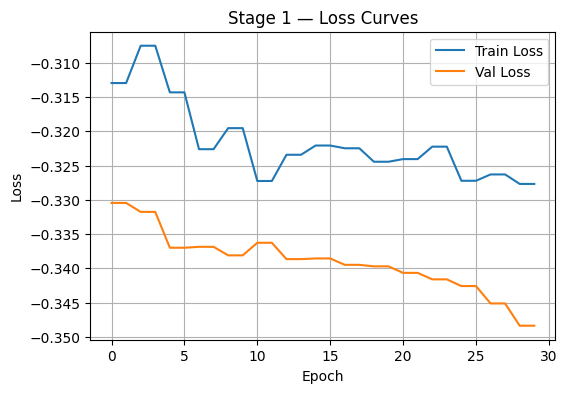

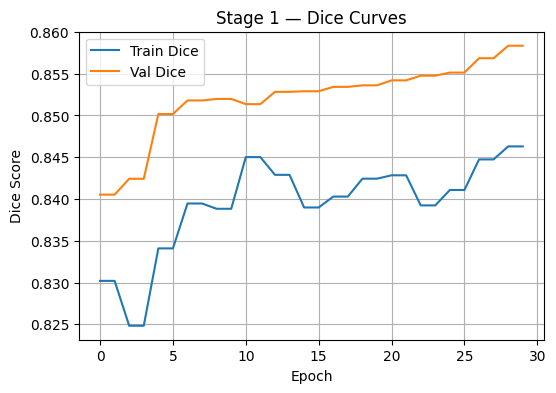

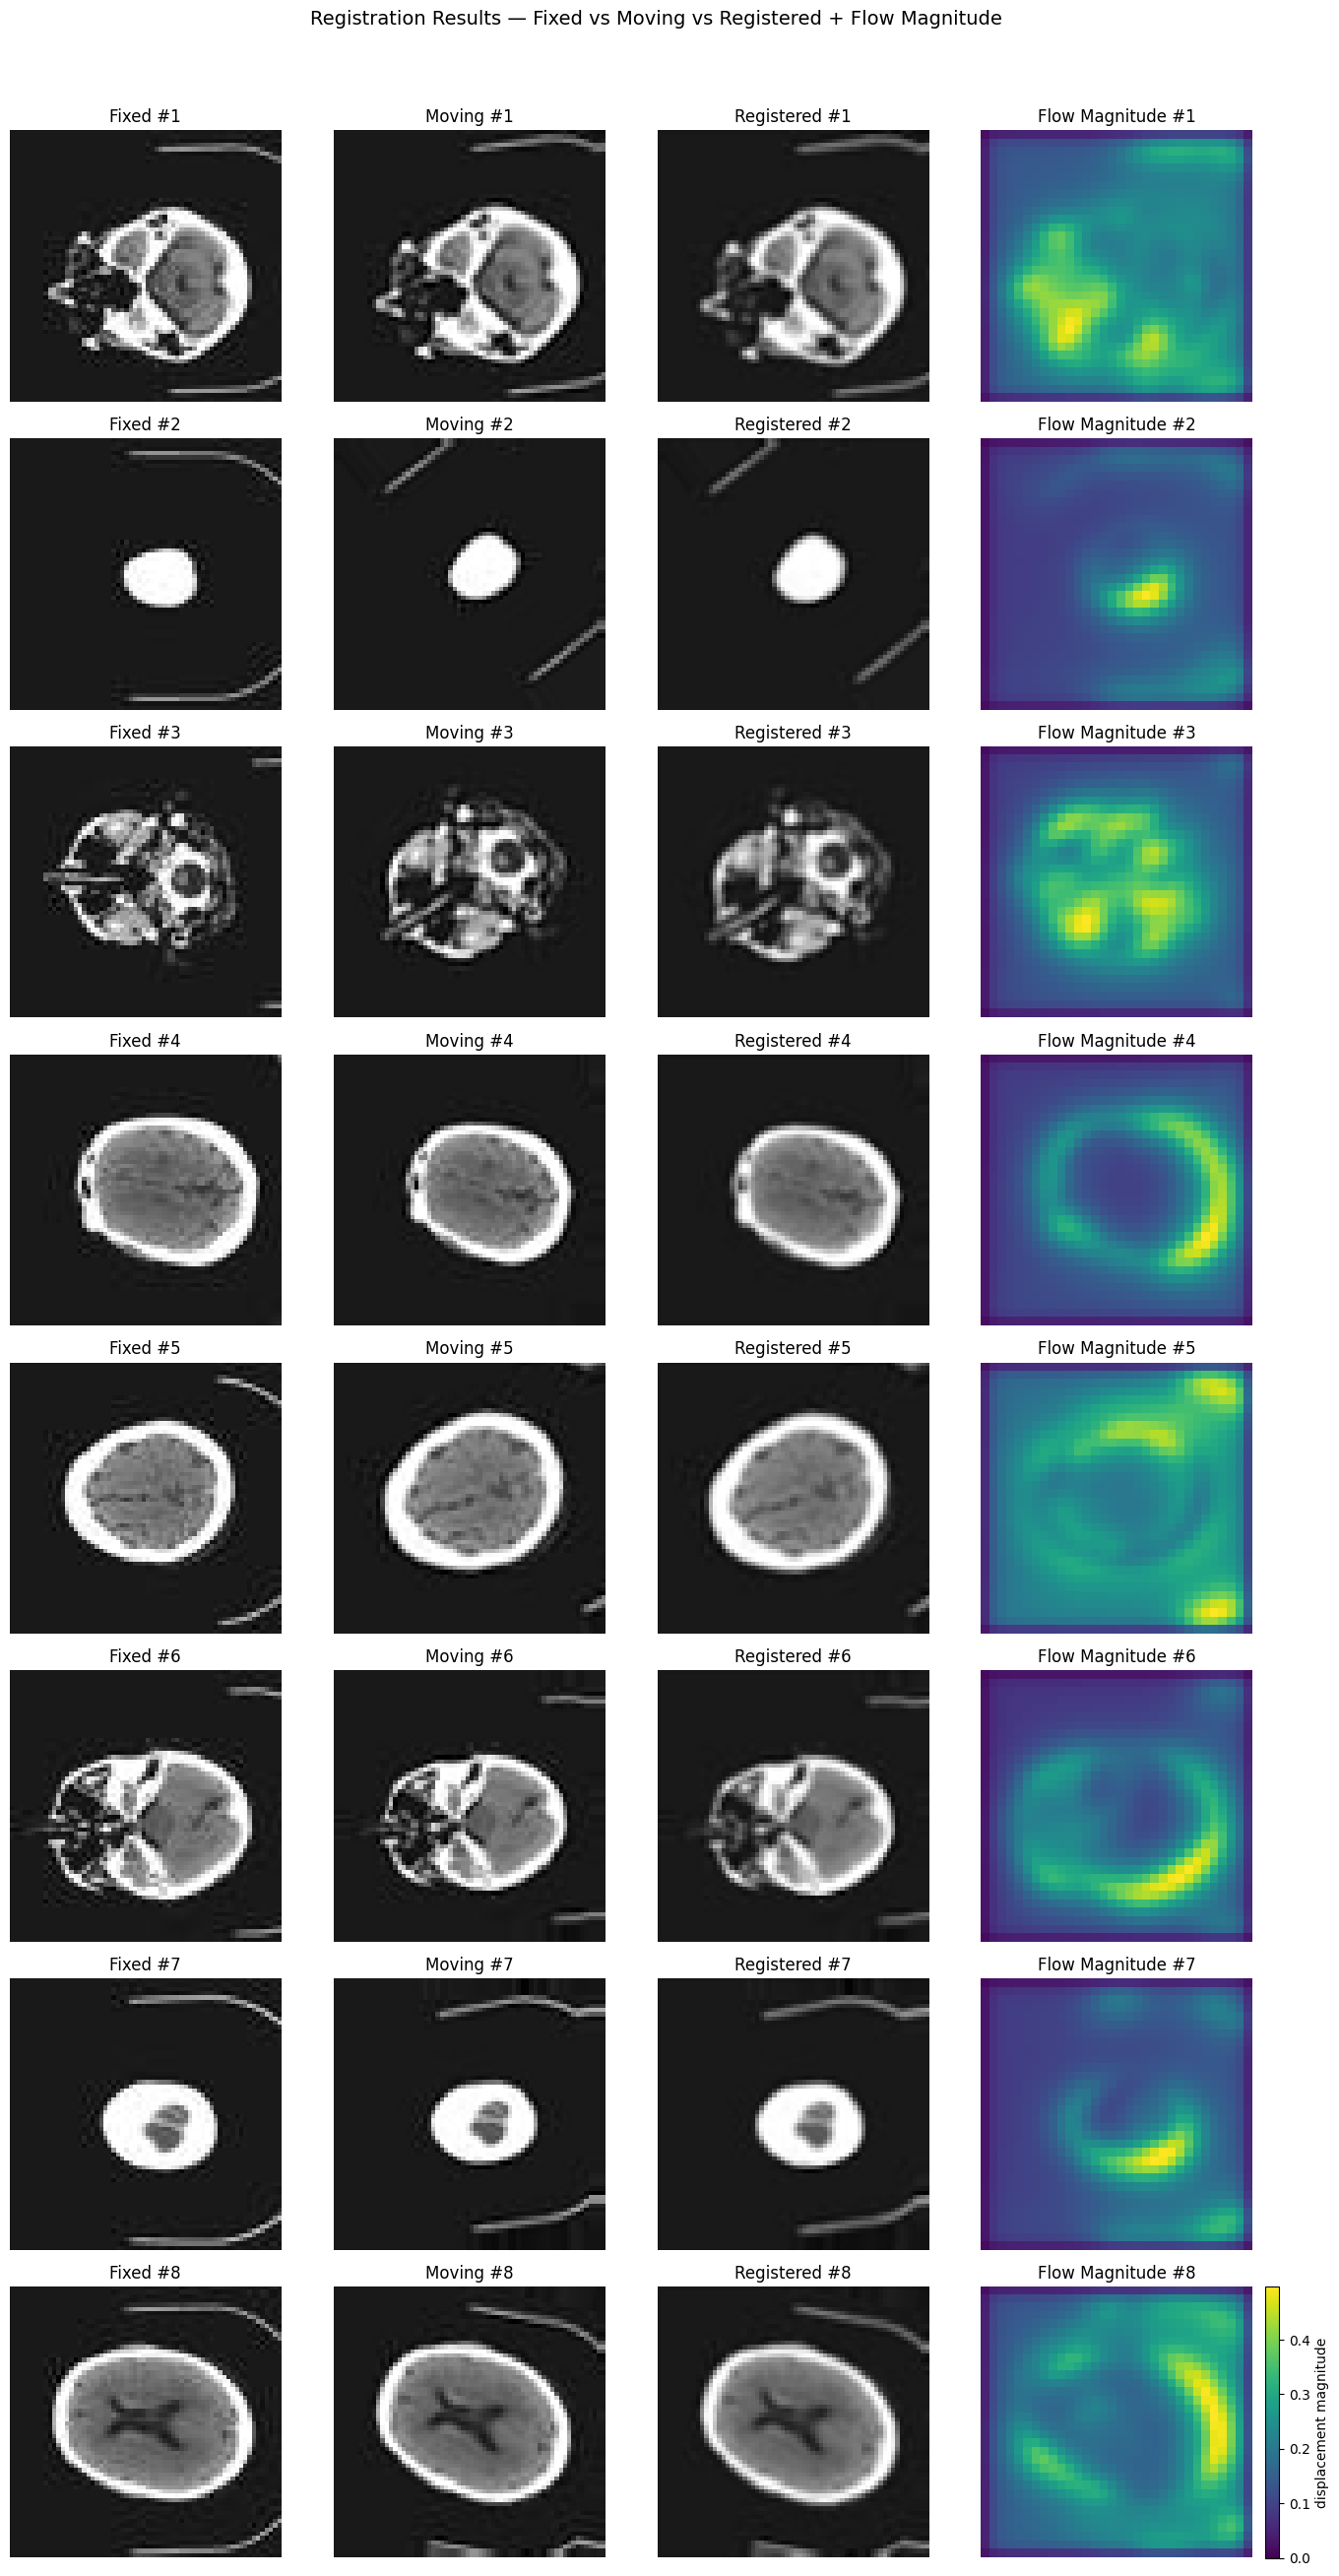

In [21]:
# ============================================================
# Cell 20 — Plots & Samples After Stage 1
# ============================================================

import matplotlib.pyplot as plt

# ---- Plot Loss ----
plt.figure(figsize=(6,4))
plt.plot(train_loss_history, label="Train Loss")
plt.plot(val_loss_history, label="Val Loss")
plt.title("Stage 1 — Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# ---- Plot Dice ----
plt.figure(figsize=(6,4))
plt.plot(train_dice_history, label="Train Dice")
plt.plot(val_dice_history, label="Val Dice")
plt.title("Stage 1 — Dice Curves")
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.legend()
plt.grid(True)
plt.show()

# ---- Plot Sample Registration Results ----
# Use a fresh batch from val_loader so we have a full batch (e.g., 16 samples)
val_batch = next(iter(val_loader))

fixed_batch  = val_batch["fixed_img"].to(device)
moving_batch = val_batch["moving_img"].to(device)

with torch.no_grad():
    registered_batch, flow_batch = voxelmorph(moving_batch, fixed_batch)

plot_samples(
    fixed_batch,
    moving_batch,
    registered_batch,
    flow_batch,
    k=8
)



In [22]:
# ============================================================
# Cell 21 — Training Stage 2 (Continue Training)
# ============================================================

num_epochs_stage2 = 40   # total epochs (e.g., extend from 15 → 40)

print(f"=== Stage 2: Continue training up to {num_epochs_stage2} epochs (same λ) ===")

for epoch in range(num_epochs_stage1, num_epochs_stage2):
    train_loss, train_dice = train_one_epoch(epoch)
    val_loss, val_dice     = validate_one_epoch(epoch)

    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)
    train_dice_history.append(train_dice)
    val_dice_history.append(val_dice)

    print(f"[Stage2] Epoch {epoch+1:3d}/{num_epochs_stage2:3d} "
          f"- Train Loss: {train_loss:.4f}, Train Dice: {train_dice:.4f} "
          f"- Val Loss: {val_loss:.4f}, Val Dice: {val_dice:.4f}")


=== Stage 2: Continue training up to 40 epochs (same λ) ===


[Stage2] Epoch  16/ 40 - Train Loss: -0.3345, Train Dice: 0.8485 - Val Loss: -0.3556, Val Dice: 0.8612


[Stage2] Epoch  17/ 40 - Train Loss: -0.3379, Train Dice: 0.8510 - Val Loss: -0.3606, Val Dice: 0.8651


[Stage2] Epoch  18/ 40 - Train Loss: -0.3389, Train Dice: 0.8527 - Val Loss: -0.3639, Val Dice: 0.8670


[Stage2] Epoch  19/ 40 - Train Loss: -0.3462, Train Dice: 0.8599 - Val Loss: -0.3716, Val Dice: 0.8710


...

[Stage2] Epoch  36/ 40 - Train Loss: -0.3821, Train Dice: 0.8858 - Val Loss: -0.4060, Val Dice: 0.8970


[Stage2] Epoch  37/ 40 - Train Loss: -0.3843, Train Dice: 0.8856 - Val Loss: -0.4085, Val Dice: 0.8980


[Stage2] Epoch  38/ 40 - Train Loss: -0.3892, Train Dice: 0.8883 - Val Loss: -0.4095, Val Dice: 0.8988


[Stage2] Epoch  39/ 40 - Train Loss: -0.3882, Train Dice: 0.8890 - Val Loss: -0.4101, Val Dice: 0.8996


[Stage2] Epoch  40/ 40 - Train Loss: -0.3923, Train Dice: 0.8901 - Val Loss: -0.4134, Val Dice: 0.9011


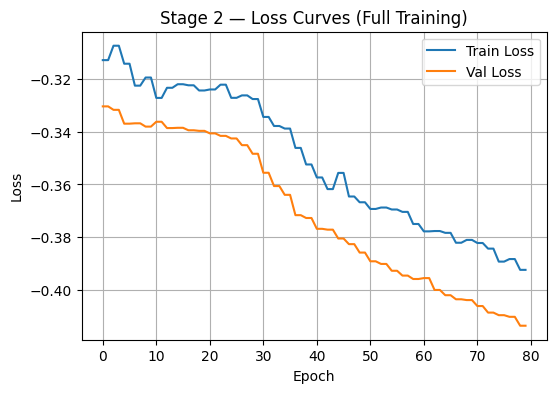

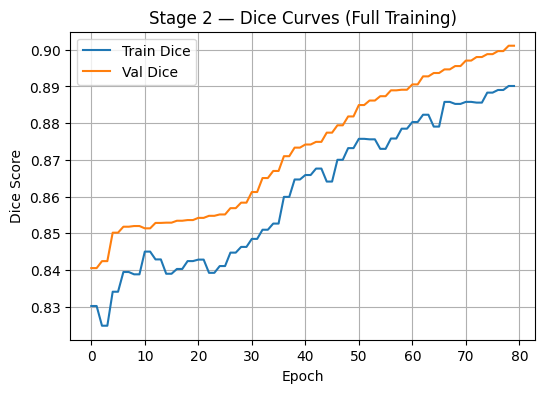

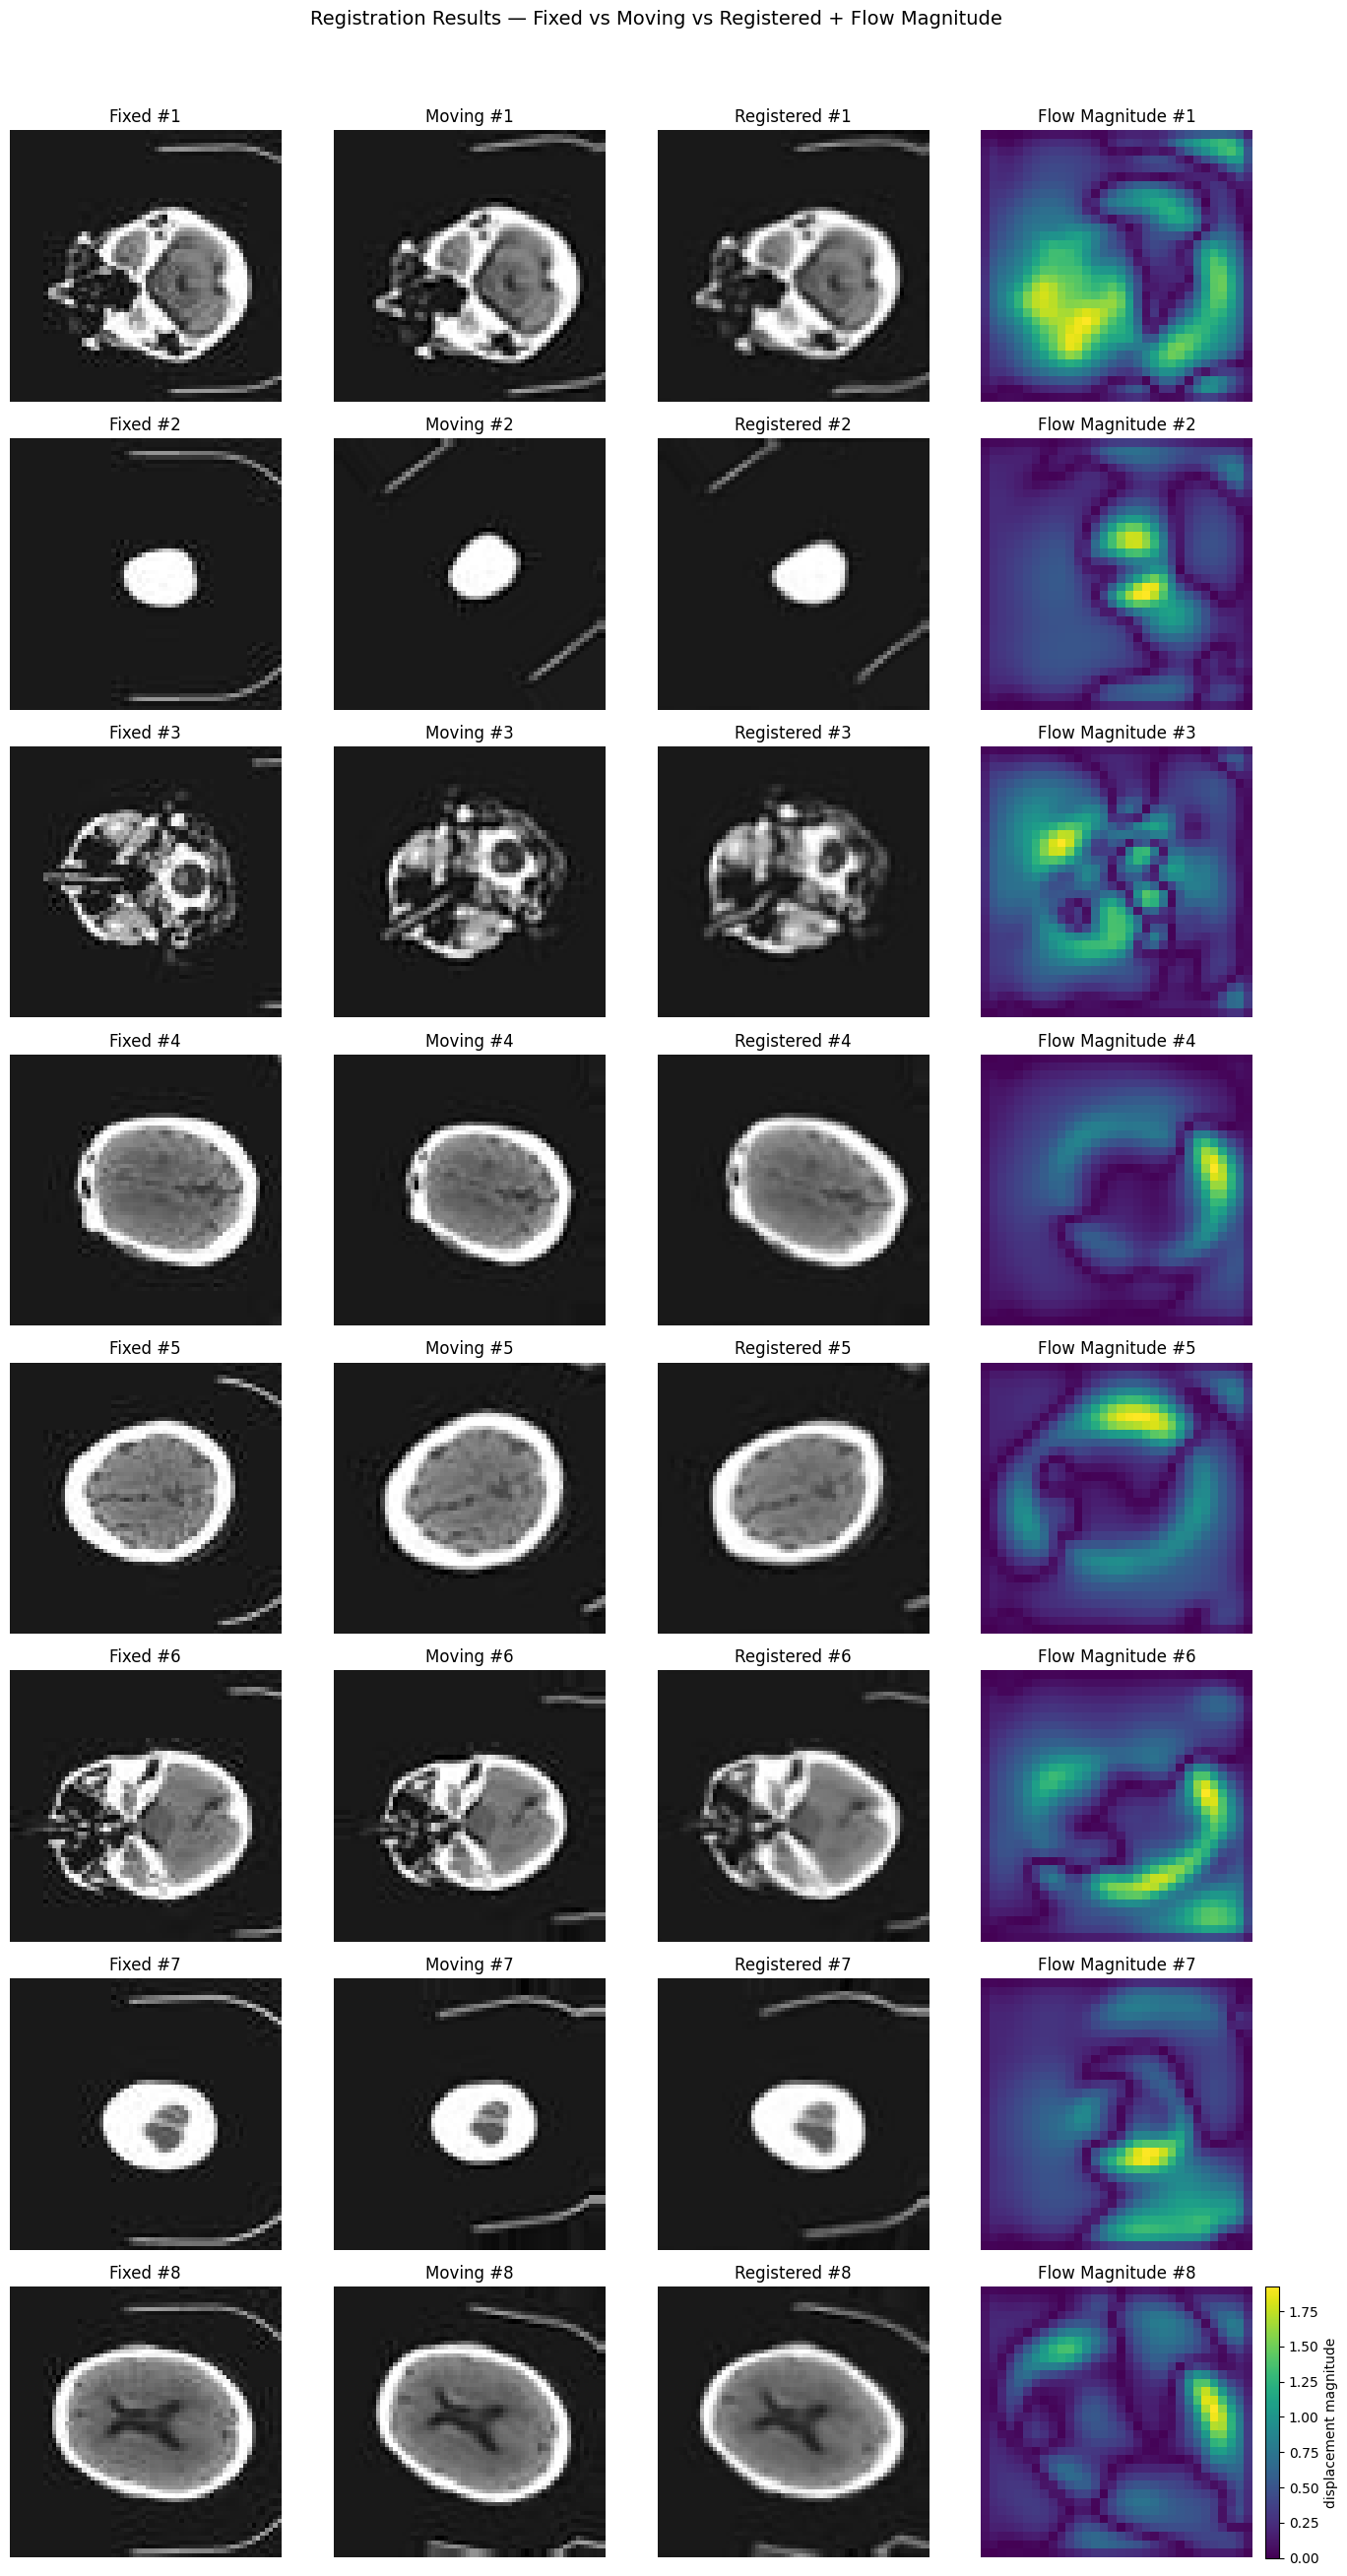

In [23]:
# ============================================================
# Cell 22 — Plots & Samples After Stage 2
# ============================================================

# ---- Plot Loss ----
plt.figure(figsize=(6,4))
plt.plot(train_loss_history, label="Train Loss")
plt.plot(val_loss_history, label="Val Loss")
plt.title("Stage 2 — Loss Curves (Full Training)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# ---- Plot Dice ----
plt.figure(figsize=(6,4))
plt.plot(train_dice_history, label="Train Dice")
plt.plot(val_dice_history, label="Val Dice")
plt.title("Stage 2 — Dice Curves (Full Training)")
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.legend()
plt.grid(True)
plt.show()

# ---- Plot Sample Registration ----
val_batch = next(iter(val_loader))

fixed_batch  = val_batch["fixed_img"].to(device)
moving_batch = val_batch["moving_img"].to(device)

with torch.no_grad():
    registered_batch, flow_batch = voxelmorph(moving_batch, fixed_batch)

plot_samples(
    fixed_batch,
    moving_batch,
    registered_batch,
    flow_batch,
    k=8
)



In [24]:
# ============================================================
# Cell 23 — Setup Second Training Experiment with New λ
# ============================================================

lambda_smooth_2 = 0.1    # <— choose a different λ
num_epochs_2    = 40      # same training length as Stage 2

print(f"=== Experiment 2: Training with λ₂ = {lambda_smooth_2} for {num_epochs_2} epochs ===")

# Build the second model
voxelmorph_2 = VxmDense(
    inshape=inshape,
    nb_unet_features=[enc_nf, dec_nf],
    src_feats=1,
    trg_feats=1,
).to(device)

criterion_2  = VoxelLoss(lambda_smooth_2)
optimizer_2  = torch.optim.Adam(voxelmorph_2.parameters(), lr=learning_rate)

# Reset histories for experiment 2
train_loss_history_exp2 = []
val_loss_history_exp2   = []
train_dice_history_exp2 = []
val_dice_history_exp2   = []


=== Experiment 2: Training with λ₂ = 0.1 for 40 epochs ===


In [25]:
# ============================================================
# Cell 24 — Training Loop for Experiment 2 (λ₂)
# ============================================================

from tqdm import tqdm

for epoch in range(num_epochs_2):
    # ---------------------------
    # Training phase
    # ---------------------------
    voxelmorph_2.train()
    train_loss_meter = RunningAverage()
    train_dice_meter = RunningAverage()

    train_loader_tqdm = tqdm(
        train_loader,
        desc=f"Exp2 — Train Epoch {epoch+1}/{num_epochs_2}",
        leave=False
    )

    for batch in train_loader_tqdm:
        # fixed و moving را از batch بگیر و روی device بفرست
        fixed_img  = batch["fixed_img"].to(device)
        moving_img = batch["moving_img"].to(device)

        optimizer_2.zero_grad()

        # moving = source, fixed = target
        registered_img, flow = voxelmorph_2(moving_img, fixed_img)

        loss = criterion_2(fixed_img, registered_img, flow)
        loss.backward()
        optimizer_2.step()

        dice = pseudo_dice(fixed_img, registered_img)

        batch_size_cur = fixed_img.size(0)
        train_loss_meter.update(loss.item(), n=batch_size_cur)
        train_dice_meter.update(dice.item(), n=batch_size_cur)

        train_loader_tqdm.set_postfix(
            loss=f"{train_loss_meter.avg:.4f}",
            dice=f"{train_dice_meter.avg:.4f}",
        )

    train_loss = train_loss_meter.avg
    train_dice = train_dice_meter.avg
    train_loss_history_exp2.append(train_loss)
    train_dice_history_exp2.append(train_dice)

    # ---------------------------
    # Validation phase
    # ---------------------------
    voxelmorph_2.eval()
    val_loss_meter = RunningAverage()
    val_dice_meter = RunningAverage()

    val_loader_tqdm = tqdm(
        val_loader,
        desc=f"Exp2 — Val   Epoch {epoch+1}/{num_epochs_2}",
        leave=False
    )

    with torch.no_grad():
        for batch in val_loader_tqdm:
            fixed_img  = batch["fixed_img"].to(device)
            moving_img = batch["moving_img"].to(device)

            registered_img, flow = voxelmorph_2(moving_img, fixed_img)

            loss = criterion_2(fixed_img, registered_img, flow)
            dice = pseudo_dice(fixed_img, registered_img)

            batch_size_cur = fixed_img.size(0)
            val_loss_meter.update(loss.item(), n=batch_size_cur)
            val_dice_meter.update(dice.item(), n=batch_size_cur)

            # آخرین batch اعتبارسنجی برای visualization
            last_val_fixed_exp2      = fixed_img.detach()
            last_val_moving_exp2     = moving_img.detach()
            last_val_registered_exp2 = registered_img.detach()
            last_val_flow_exp2       = flow.detach()

            val_loader_tqdm.set_postfix(
                loss=f"{val_loss_meter.avg:.4f}",
                dice=f"{val_dice_meter.avg:.4f}",
            )

    val_loss = val_loss_meter.avg
    val_dice = val_dice_meter.avg
    val_loss_history_exp2.append(val_loss)
    val_dice_history_exp2.append(val_dice)

    print(
        f"[Exp2] Epoch {epoch+1:3d}/{num_epochs_2:3d} "
        f"- Train Loss: {train_loss:.4f}, Train Dice: {train_dice:.4f} "
        f"- Val Loss: {val_loss:.4f}, Val Dice: {val_dice:.4f}"
    )


[Exp2] Epoch   1/ 40 - Train Loss: -0.3105, Train Dice: 0.8303 - Val Loss: -0.3305, Val Dice: 0.8404


[Exp2] Epoch   2/ 40 - Train Loss: -0.3110, Train Dice: 0.8257 - Val Loss: -0.3319, Val Dice: 0.8420


[Exp2] Epoch   3/ 40 - Train Loss: -0.3118, Train Dice: 0.8287 - Val Loss: -0.3378, Val Dice: 0.8480


[Exp2] Epoch   4/ 40 - Train Loss: -0.3212, Train Dice: 0.8414 - Val Loss: -0.3395, Val Dice: 0.8492


[Exp2] Epoch   5/ 40 - Train Loss: -0.3226, Train Dice: 0.8377 - Val Loss: -0.3408, Val Dice: 0.8506


...

[Exp2] Epoch  36/ 40 - Train Loss: -0.3779, Train Dice: 0.8825 - Val Loss: -0.3861, Val Dice: 0.8874


[Exp2] Epoch  37/ 40 - Train Loss: -0.3749, Train Dice: 0.8804 - Val Loss: -0.4044, Val Dice: 0.8957


[Exp2] Epoch  38/ 40 - Train Loss: -0.3834, Train Dice: 0.8841 - Val Loss: -0.4017, Val Dice: 0.8955


[Exp2] Epoch  39/ 40 - Train Loss: -0.3794, Train Dice: 0.8851 - Val Loss: -0.4054, Val Dice: 0.8965


[Exp2] Epoch  40/ 40 - Train Loss: -0.3866, Train Dice: 0.8868 - Val Loss: -0.4014, Val Dice: 0.8951


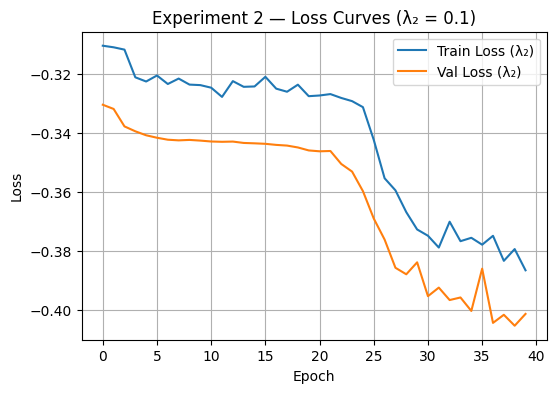

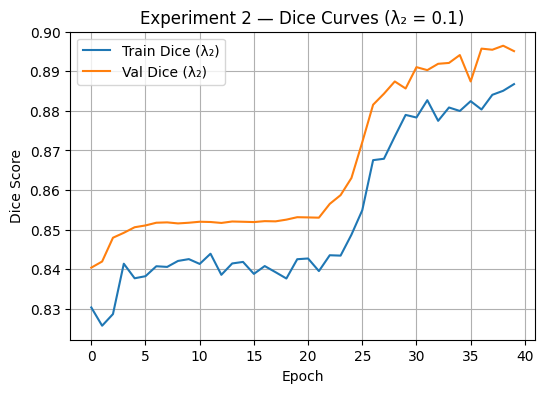

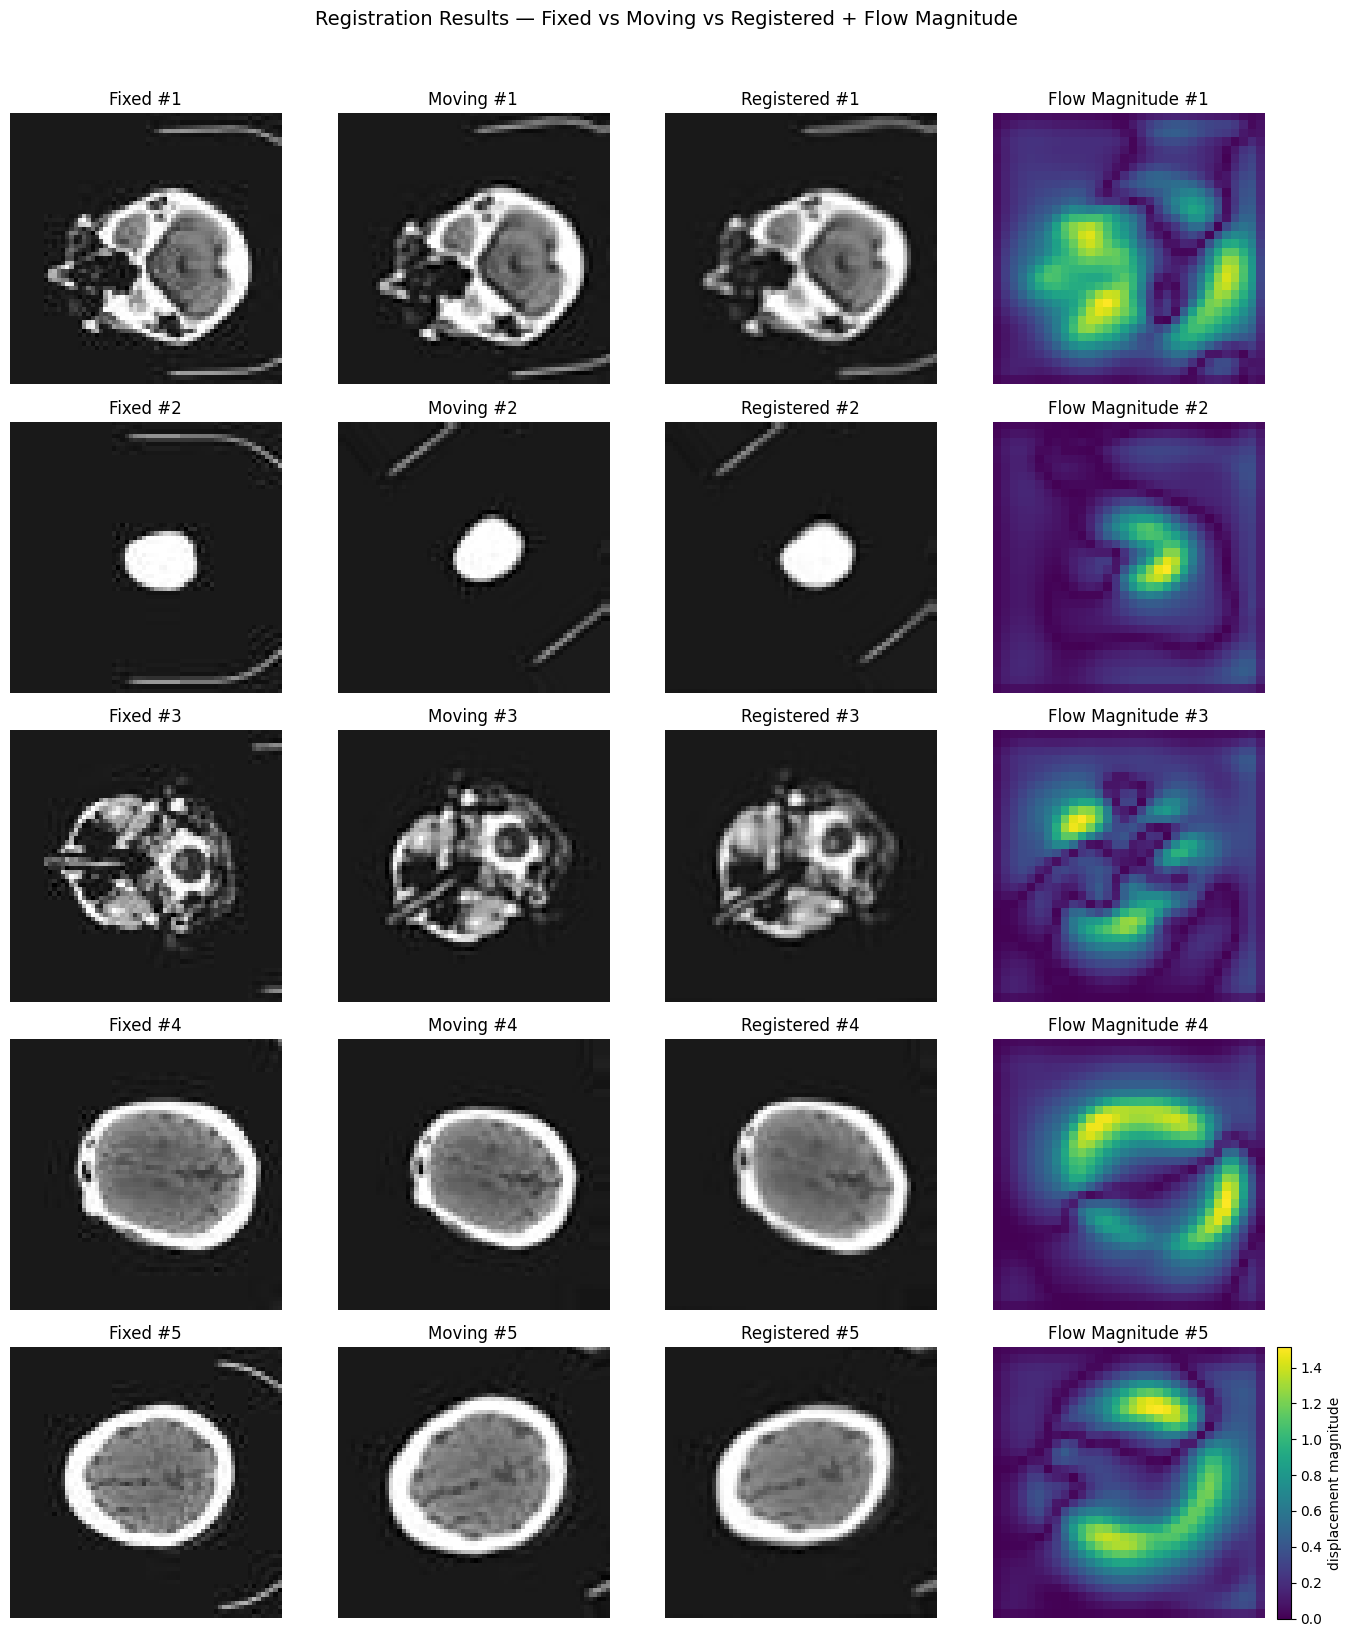

In [26]:
# ============================================================
# Cell 25 — Plots & Samples for Experiment 2 (λ₂)
# ============================================================

# ---- Loss Curves ----
plt.figure(figsize=(6, 4))
plt.plot(train_loss_history_exp2, label="Train Loss (λ₂)")
plt.plot(val_loss_history_exp2,   label="Val Loss (λ₂)")
plt.title(f"Experiment 2 — Loss Curves (λ₂ = {lambda_smooth_2})")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# ---- Dice Curves ----
plt.figure(figsize=(6, 4))
plt.plot(train_dice_history_exp2, label="Train Dice (λ₂)")
plt.plot(val_dice_history_exp2,   label="Val Dice (λ₂)")
plt.title(f"Experiment 2 — Dice Curves (λ₂ = {lambda_smooth_2})")
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.legend()
plt.grid(True)
plt.show()

# ---- Registration Samples (Experiment 2, λ₂) ----
val_batch = next(iter(val_loader))

fixed_batch_exp2  = val_batch["fixed_img"].to(device)
moving_batch_exp2 = val_batch["moving_img"].to(device)

with torch.no_grad():
    registered_batch_exp2, flow_batch_exp2 = voxelmorph_2(moving_batch_exp2, fixed_batch_exp2)

plot_samples(
    fixed_batch_exp2,
    moving_batch_exp2,
    registered_batch_exp2,
    flow_batch_exp2,
    k=5
)

